# Main VG - Variance Gamma Option Pricing

This notebook runs the QMC Fourier pricing engine for a **Variance Gamma (VG)** model with a **cash-or-nothing put** payoff.

## 1. Imports - Dependencies & Functions

In [1]:
# External dependencies (numpy, scipy, qmcpy are used by the modules below)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as ss
import warnings
warnings.filterwarnings("ignore")

# Models: covariance_matrix, VGModel, NIGModel, GHModel, GBMModel
from models import covariance_matrix, VGModel, NIGModel, GHModel, GBMModel

# Payoffs: CallOnMin, PutOnMax, BasketPut, SpreadCall, CashOrNothingPut
from payoffs import CallOnMin, PutOnMax, BasketPut, SpreadCall, CashOrNothingPut

# Domain transformations: MLTransform, MSTransform, MNTransform
from domain_transformation import MLTransform, MSTransform, MNTransform

# Damping optimization: optimize_damping_parameters
from damping_optimization import optimize_damping_parameters

# Pricing engine: QMC_fourier_pricing_engine, PricingEngine
from pricing_engine import QMC_fourier_pricing_engine, PricingEngine

## 2. Define Parameters

In [2]:
model_name = 'VG'
payoff_name = 'call_on_min'

# VG model parameters
d = 2
S0 = 100 * np.ones(d)
K = 100
r = 0
q = 0
T = 1
nu = 0.001
sigma = 0.4 * np.ones(d)
theta = -0.3 * np.ones(d)
rho = np.identity(d)
SIGMA = covariance_matrix(sigma, rho)

VG_option_params = (d, S0, K, r, q, T, SIGMA, theta, nu)

# QMC parameters
N_samples = 2**7
S_shifts = 30
TOLR = 1e-3  # Set to a target relative error (e.g., 0.01) for adaptive sampling

## 3. Run Pricing & Display Results

In [3]:
print("Covariance matrix:")
print(SIGMA)
print()

price_estimate, error_estimate = QMC_fourier_pricing_engine(
    model_name,
    payoff_name,
    VG_option_params,
    N_samples,
    S_shifts,
    transform_distribution=None,
    transform_params=None,
    TOLR=TOLR
)

print(f"Estimated Price: {round(price_estimate, 5)}, Statistical Error: {round(error_estimate, 5)}, Relative Error: {round(error_estimate / price_estimate, 5)}")

Covariance matrix:
[[0.16 0.  ]
 [0.   0.16]]

R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
Estimated Price: 3.46363, Statistical Error: 0.00315, Relative Error: 0.00091


## 4. QMC Convergence Study

Log-log plot of convergence with **fixed S** (S_shifts) and **varying N** (N_samples).

R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]


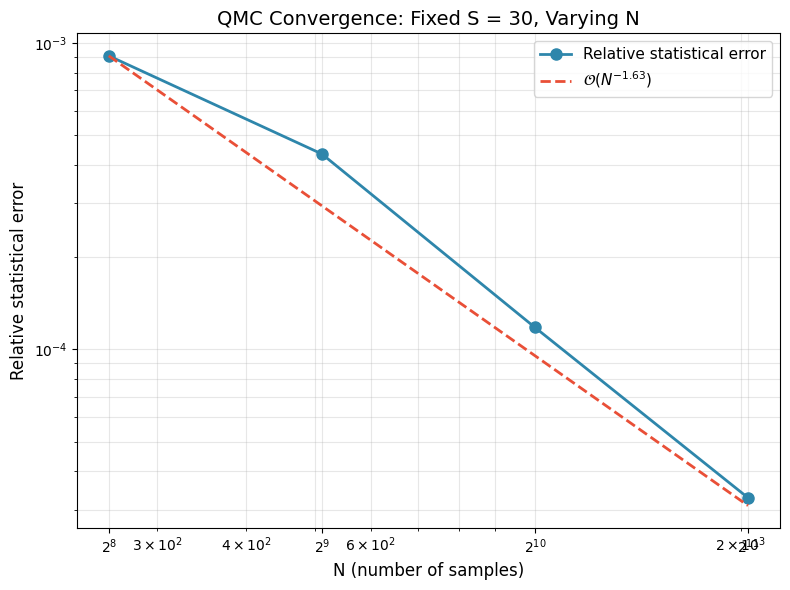

Fitted convergence rate: r = 0.000


In [4]:
# Fixed S, varying N - convergence study
S_fixed = 30
N_values = 2 ** np.arange(8, 12)  # N = 16, 32, 64, ..., 1024

relative_statistical_errors = []

for N in N_values:
    price, stat_error = QMC_fourier_pricing_engine(
        model_name,
        payoff_name,
        VG_option_params,
        N,
        S_fixed,
        transform_distribution=None,
        transform_params=None,
        TOLR=None  # No adaptive sampling - use exact N
    )
    relative_statistical_errors.append(stat_error / price)

# Fit O(N^{-r}) in log-log space: log(error) = log(C) - r * log(N)
log_N = np.log(N_values)
log_err = np.log(relative_statistical_errors)
coeffs = np.polyfit(log_N, log_err, 1)  # Linear fit: slope = -r, intercept = log(C)
conv_rate = -coeffs[0]  # Convergence rate (do not overwrite r = risk-free rate!)

# Fit constant C so the line passes through the first data point
C = relative_statistical_errors[0] * (N_values[0] ** conv_rate)
fitted_errors = C * (N_values ** (-conv_rate))

# Log-log plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(N_values, relative_statistical_errors, 'o-', label='Relative statistical error', color='#2E86AB', linewidth=2, markersize=8)
ax.loglog(N_values, fitted_errors, '--', label=rf'$\mathcal{{O}}(N^{{-{conv_rate:.2f}}})$', color='#E94F37', linewidth=2)

ax.set_xlabel('N (number of samples)', fontsize=12)
ax.set_ylabel('Relative statistical error', fontsize=12)
ax.set_title(f'QMC Convergence: Fixed S = {S_fixed}, Varying N', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(N_values)
ax.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in N_values])
plt.tight_layout()
plt.show()

print(f"Fitted convergence rate: r = {r:.3f}")

## 5. Non-Diagonal Example  Call on min

Six-dimensional VG options with correlation structure $\rho_{ij} = \frac{0.2}{1+0.1|i-j|}$ and $\Sigma_{ij} = \rho_{ij} \sigma_i \sigma_j$.

**Parameters:** $S_0^j=100$, $K=100$, $r=0$, $T=1$, $\sigma_j=0.4$, $\theta_j=-0.3$, $\nu=0.1$ for all $j=1,\ldots,d$.

**Options:** (a) Cash-or-nothing put (CON), (b) Call on min.

**Domain transformation:** MS (Multivariate Student-t) with $\Sigma_{IS} = \Sigma^{-1}$, $\nu_{IS} = 2T/\nu - d$ (Table 3).

In [5]:
# Non-diagonal covariance: rho_ij = 0.2 / (1 + 0.1|i-j|), Sigma_ij = rho_ij * sigma_i * sigma_j
d_nd = 2
S0_nd = 100 * np.ones(d_nd)
K_nd = 100
r_nd, q_nd, T_nd = 0, 0, 1
sigma_nd = 0.4 * np.ones(d_nd)
theta_nd = -0.3 * np.ones(d_nd)
nu_nd = 0.1

# Build correlation matrix: rho_ij = 0.2 / (1 + 0.1|i-j|), diagonal = 1
rho_nd = np.zeros((d_nd, d_nd))
for i in range(d_nd):
    for j in range(d_nd):
        if i == j:
            rho_nd[i, j] = 1.0
        else:
            rho_nd[i, j] = 0.2 / (1 + 0.1 * np.abs(i - j))

SIGMA_nd = covariance_matrix(sigma_nd, rho_nd)
VG_params_nd = (d_nd, S0_nd, K_nd, r_nd, q_nd, T_nd, SIGMA_nd, theta_nd, nu_nd)

# Domain transformation (Table 3): MS with Sigma_IS = inv(Sigma), nu_IS = 2*T/nu - d
import scipy.linalg as la
transform_params_nd = (la.inv(SIGMA_nd), 2 * T_nd / nu_nd - d_nd)

N_nd, S_nd = 2**10, 30

print("Correlation matrix rho_ij = 0.2/(1+0.1|i-j|):")
print(rho_nd)
print("\nCovariance matrix Sigma_ij = rho_ij * sigma_i * sigma_j:")
print(SIGMA_nd)

Correlation matrix rho_ij = 0.2/(1+0.1|i-j|):
[[1.         0.18181818]
 [0.18181818 1.        ]]

Covariance matrix Sigma_ij = rho_ij * sigma_i * sigma_j:
[[0.16       0.02909091]
 [0.02909091 0.16      ]]


### Plain Monte Carlo reference value computation

High-fidelity MC reference values (M=10⁷, B=10) for uncorrelated and correlated cases. Computed once; used for relative actual error in the convergence plot below.

In [6]:
import scipy.stats as ss

def MC_call_on_min_VG_pricer(S0, K, r, T, sigma, rho, theta, nu, B, N, M, alpha_conf, seed):
    """
    Compute call-on-min price under VG. Original sequential implementation from MC_VG.ipynb.
    (Parallelization was reverted — it introduced divergence from QMC for the correlated case.)
    """
    np.random.seed(seed)
    dimension = len(S0)
    SIGMA = covariance_matrix(sigma, rho)
    L = np.linalg.cholesky(rho)
    price_estimates_per_batch = np.zeros(B)
    price_stds_per_batch = np.zeros(B)
    N = 1
    dt = T / N
    alpha = dt / nu
    beta = 1 / nu
    mu = (1 / nu) * np.log(1 - nu * theta - 0.5 * nu * np.diag(SIGMA))

    for b in range(B):
        X = np.zeros((M, N + 1, dimension))
        Z = np.random.multivariate_normal(np.zeros(dimension), np.eye(dimension), size=(M, N))
        G = ss.gamma.rvs(a=alpha, scale=1 / beta, size=(M, N))
        for n in range(N):
            for m in range(M):
                W_correlated = L @ Z[m, n, :]
                X[m, n + 1, :] = X[m, n, :] + (r + mu) * dt + theta * G[m, n] + sigma * np.sqrt(G[m, n]) * W_correlated
        XT = X[:, -1, :]
        ST = S0 * np.exp(XT)
        payoff_evals = np.exp(-r * T) * np.maximum(np.min(ST, axis=1) - K, 0)
        price_estimates_per_batch[b] = np.mean(payoff_evals)
        price_stds_per_batch[b] = np.std(payoff_evals)

    price_estimate = np.mean(price_estimates_per_batch)
    C_alpha = norm.ppf(1 - alpha_conf / 2)
    MC_stat_error = C_alpha * np.mean(price_stds_per_batch) / np.sqrt(M * B)
    return price_estimate, MC_stat_error

In [7]:
# High-fidelity MC reference (M=10^7, B=10) - run once, reuse for convergence plot
M_ref, B_ref = 10**5, 10
alpha_conf, seed = 0.05, 100

# Uncorrelated reference
MC_ref_uncorr, MC_err_uncorr = MC_call_on_min_VG_pricer(S0, K, r, T, sigma, rho, theta, nu, B_ref, 1, M_ref, alpha_conf, seed)

# Correlated reference (use nu_nd, sigma_nd, theta_nd, rho_nd, etc.)
MC_ref_corr, MC_err_corr = MC_call_on_min_VG_pricer(S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_ref, 1, M_ref, alpha_conf, seed + 1)

print(f"MC reference (Uncorrelated): price = {MC_ref_uncorr:.6f}, rel stat err = {MC_err_uncorr/MC_ref_uncorr:.6f}")
print(f"  Payoff: {payoff_name}, Model: VG, d={d}, S0={S0[0]}, K={K}, r={r}, T={T}, nu={nu}, sigma={sigma[0]}")
print(f"MC reference (Correlated):   price = {MC_ref_corr:.6f}, rel stat err = {MC_err_corr/MC_ref_corr:.6f}")
print(f"  Payoff: {payoff_name}, Model: VG, d={d_nd}, S0={S0_nd[0]}, K={K_nd}, r={r_nd}, T={T_nd}, nu={nu_nd}, sigma={sigma_nd[0]}")

MC reference (Uncorrelated): price = 3.466371, rel stat err = 0.006102
  Payoff: call_on_min, Model: VG, d=2, S0=100.0, K=100, r=0, T=1, nu=0.001, sigma=0.4
MC reference (Correlated):   price = 4.700403, rel stat err = 0.005395
  Payoff: call_on_min, Model: VG, d=2, S0=100.0, K=100, r=0, T=1, nu=0.1, sigma=0.4


### Comparison: Original vs parallelized MC (M=10⁵, B=10)

Compare the original sequential MC against the parallelized/vectorized version to check for divergence.

In [10]:
from concurrent.futures import ProcessPoolExecutor
import os

def MC_call_on_min_VG_pricer_parallel(S0, K, r, T, sigma, rho, theta, nu, B, N, M, alpha_conf, seed, n_jobs=1):
    """Parallelized + vectorized MC (version that was reverted)."""
    dimension = len(S0)
    SIGMA = covariance_matrix(sigma, rho)
    L = np.linalg.cholesky(rho)
    N = 1
    dt = T / N
    alpha = dt / nu
    beta = 1 / nu
    mu = (1 / nu) * np.log(1 - nu * theta - 0.5 * nu * np.diag(SIGMA))

    def run_batch(b):
        np.random.seed(seed + b)
        Z = np.random.multivariate_normal(np.zeros(dimension), np.eye(dimension), size=(M, N))
        G = ss.gamma.rvs(a=alpha, scale=1 / beta, size=(M, N))
        W = Z @ L.T
        drift = (r + mu) * dt + theta * G[:, :, np.newaxis]
        diff = sigma * np.sqrt(G)[:, :, np.newaxis] * W
        XT = drift + diff
        ST = S0 * np.exp(XT[:, -1, :])
        payoffs = np.exp(-r * T) * np.maximum(np.min(ST, axis=1) - K, 0)
        return np.mean(payoffs), np.std(payoffs)

    if n_jobs == 1 or (n_jobs is not None and n_jobs < 2):
        results = [run_batch(b) for b in range(B)]
    else:
        n_workers = max(1, os.cpu_count() - 1) if n_jobs in (-1, None) else n_jobs
        with ProcessPoolExecutor(max_workers=n_workers) as pool:
            results = list(pool.map(run_batch, range(B)))

    prices = np.array([x[0] for x in results])
    stds = np.array([x[1] for x in results])
    price_estimate = np.mean(prices)
    C_alpha = norm.ppf(1 - alpha_conf / 2)
    MC_stat_error = C_alpha * np.mean(stds) / np.sqrt(M * B)
    return price_estimate, MC_stat_error

# Compare with M=10**5, B=10
M_cmp, B_cmp = 10**5, 10
alpha_conf, seed = 0.05, 100

print("=== Uncorrelated (rho=identity) ===")
p_orig_u, e_orig_u = MC_call_on_min_VG_pricer(S0, K, r, T, sigma, rho, theta, nu, B_cmp, 1, M_cmp, alpha_conf, seed)
p_par_u, e_par_u = MC_call_on_min_VG_pricer_parallel(S0, K, r, T, sigma, rho, theta, nu, B_cmp, 1, M_cmp, alpha_conf, seed, n_jobs=1)
print(f"Original:   price = {p_orig_u:.6f}, stat err = {e_orig_u:.6f}")
print(f"Parallel:   price = {p_par_u:.6f}, stat err = {e_par_u:.6f}")
print(f"Difference: {abs(p_orig_u - p_par_u):.6f} (rel: {abs(p_orig_u - p_par_u)/p_orig_u*100:.4f}%)")

print("\n=== Correlated (rho non-diagonal) ===")
p_orig_c, e_orig_c = MC_call_on_min_VG_pricer(S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_cmp, 1, M_cmp, alpha_conf, seed + 1)
p_par_c, e_par_c = MC_call_on_min_VG_pricer_parallel(S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_cmp, 1, M_cmp, alpha_conf, seed + 1, n_jobs=1)
print(f"Original:   price = {p_orig_c:.6f}, stat err = {e_orig_c:.6f}")
print(f"Parallel:   price = {p_par_c:.6f}, stat err = {e_par_c:.6f}")
print(f"Difference: {abs(p_orig_c - p_par_c):.6f} (rel: {abs(p_orig_c - p_par_c)/p_orig_c*100:.4f}%)")

# Also test if parallel execution (n_jobs=-1) changes the result vs sequential (n_jobs=1)
print("\n=== Parallel n_jobs=1 vs n_jobs=-1 (correlated only) ===")
p_par1_c, _ = MC_call_on_min_VG_pricer_parallel(S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_cmp, 1, M_cmp, alpha_conf, seed + 1, n_jobs=1)
p_parN_c, _ = MC_call_on_min_VG_pricer_parallel(S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_cmp, 1, M_cmp, alpha_conf, seed + 1, n_jobs=-1)
print(f"Parallel n_jobs=1:  price = {p_par1_c:.6f}")
print(f"Parallel n_jobs=-1: price = {p_parN_c:.6f}")
print(f"Difference: {abs(p_par1_c - p_parN_c):.6f}")

=== Uncorrelated (rho=identity) ===
Original:   price = 3.466371, stat err = 0.021153
Parallel:   price = 3.468501, stat err = 0.021156
Difference: 0.002130 (rel: 0.0615%)

=== Correlated (rho non-diagonal) ===
Original:   price = 4.700403, stat err = 0.025360
Parallel:   price = 4.693775, stat err = 0.025365
Difference: 0.006628 (rel: 0.1410%)

=== Parallel n_jobs=1 vs n_jobs=-1 (correlated only) ===
Parallel n_jobs=1:  price = 4.693775
Parallel n_jobs=-1: price = 4.693775
Difference: 0.000000


### QMC computed values

Quasi-Monte Carlo Fourier pricing for uncorrelated and correlated cases (same parameters as MC).

In [11]:
# QMC values (N=2^10, S=30 - same as convergence study)
N_qmc, S_qmc = 2**10, 30

print("=== QMC Uncorrelated (rho=identity) ===")
p_qmc_u, e_qmc_u = QMC_fourier_pricing_engine('VG', payoff_name, VG_option_params, N_qmc, S_qmc,
                                              transform_distribution=None, transform_params=None, TOLR=None)
print(f"Price = {p_qmc_u:.6f}, statistical error = {e_qmc_u:.6f}, rel err = {e_qmc_u/p_qmc_u:.6f}")

print("\n=== QMC Correlated (rho non-diagonal) ===")
p_qmc_c, e_qmc_c = QMC_fourier_pricing_engine('VG', payoff_name, VG_params_nd, N_qmc, S_qmc,
                                              transform_distribution='MS', transform_params=transform_params_nd, TOLR=None)
print(f"Price = {p_qmc_c:.6f}, statistical error = {e_qmc_c:.6f}, rel err = {e_qmc_c/p_qmc_c:.6f}")

=== QMC Uncorrelated (rho=identity) ===
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
Price = 3.462545, statistical error = 0.000408, rel err = 0.000118

=== QMC Correlated (rho non-diagonal) ===
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
Price = 4.692397, statistical error = 0.000589, rel err = 0.000126


### High-fidelity MC reference (parallel version)

M=10⁷, B=10 using the parallelized MC pricer (n_jobs=-1).

In [12]:
# High-fidelity MC reference with parallel version (M=10^7, B=10, n_jobs=-1)
M_ref_par, B_ref_par = 10**7, 10
alpha_conf, seed = 0.05, 100

MC_ref_uncorr_par, MC_err_uncorr_par = MC_call_on_min_VG_pricer_parallel(
    S0, K, r, T, sigma, rho, theta, nu, B_ref_par, 1, M_ref_par, alpha_conf, seed, n_jobs=-1
)
MC_ref_corr_par, MC_err_corr_par = MC_call_on_min_VG_pricer_parallel(
    S0_nd, K_nd, r_nd, T_nd, sigma_nd, rho_nd, theta_nd, nu_nd, B_ref_par, 1, M_ref_par, alpha_conf, seed + 1, n_jobs=-1
)

print(f"MC reference parallel (Uncorrelated): price = {MC_ref_uncorr_par:.6f}, rel stat err = {MC_err_uncorr_par/MC_ref_uncorr_par:.6f}")
print(f"MC reference parallel (Correlated):   price = {MC_ref_corr_par:.6f}, rel stat err = {MC_err_corr_par/MC_ref_corr_par:.6f}")

MC reference parallel (Uncorrelated): price = 3.461137, rel stat err = 0.000610
MC reference parallel (Correlated):   price = 4.693370, rel stat err = 0.000540


### Convergence comparison: uncorrelated vs correlated (2D)

Same payoff, same dimension—compare convergence for diagonal vs non-diagonal covariance.

R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.40850656 -3.40850656]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]
R_init =  [-2. -2.]
R =  [-3.13230531 -3.13230531]


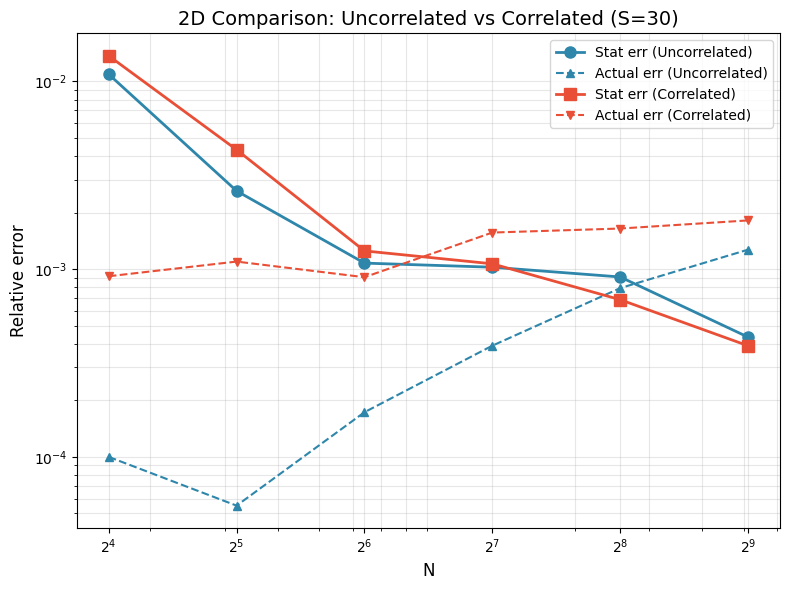

In [13]:
# Convergence: BOTH uncorrelated and correlated — stat error + actual error vs MC reference
S_fixed = 30
N_values = 2 ** np.arange(4, 10)

# Uncorrelated
prices_uncorr, stat_err_uncorr, actual_err_uncorr = [], [], []
for N in N_values:
    p, e = QMC_fourier_pricing_engine('VG', payoff_name, VG_option_params, N, S_fixed,
                                       transform_distribution=None, transform_params=None, TOLR=None)
    prices_uncorr.append(p)
    stat_err_uncorr.append(e / p)
    actual_err_uncorr.append(abs(p - MC_ref_uncorr) / MC_ref_uncorr)

# Correlated
prices_corr, stat_err_corr, actual_err_corr = [], [], []
for N in N_values:
    p, e = QMC_fourier_pricing_engine('VG', payoff_name, VG_params_nd, N, S_fixed,
                                       transform_distribution='MS', transform_params=transform_params_nd, TOLR=None)
    prices_corr.append(p)
    stat_err_corr.append(e / p)
    actual_err_corr.append(abs(p - MC_ref_corr) / MC_ref_corr)

# Plot: distinct markers (stat=circle, actual=triangle), colors (uncorr=blue, corr=red)
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(N_values, stat_err_uncorr, 'o-', label='Stat err (Uncorrelated)', color='#2E86AB', linewidth=2, markersize=8)
ax.loglog(N_values, actual_err_uncorr, '^-', label='Actual err (Uncorrelated)', color='#2E86AB', linewidth=1.5, markersize=6, linestyle='--')
ax.loglog(N_values, stat_err_corr, 's-', label='Stat err (Correlated)', color='#E94F37', linewidth=2, markersize=8)
ax.loglog(N_values, actual_err_corr, 'v-', label='Actual err (Correlated)', color='#E94F37', linewidth=1.5, markersize=6, linestyle='--')
ax.set_xlabel('N', fontsize=12)
ax.set_ylabel('Relative error', fontsize=12)
ax.set_title(f'2D Comparison: Uncorrelated vs Correlated (S={S_fixed})', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(N_values)
ax.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in N_values])
plt.tight_layout()
plt.show()